In [33]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [34]:
DATA_PATH = "/Users/Alex/Documents/FYP v.2/Traffic Intelligence/dft_rawcount_local_authority_id_141.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.2

In [35]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (72948, 32)


/var/folders/2h/vlvc2dcn6m9fx273497hnf300000gp/T/ipykernel_83118/3850633799.py:1: DtypeWarning: Columns (0: start_junction_road_name, 1: end_junction_road_name) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


,count_point_id,direction_of_travel,year,count_date,hour,region_id,region_name,local_authority_id,local_authority_name,road_name,...,buses_and_coaches,lgvs,hgvs_2_rigid_axle,hgvs_3_rigid_axle,hgvs_4_or_more_rigid_axle,hgvs_3_or_4_articulated_axle,hgvs_5_articulated_axle,hgvs_6_articulated_axle,all_hgvs,all_motor_vehicles
0,6358,N,2000,2000-05-10,10,10,West Midlands,141,Birmingham,A34,...,72,123,20,3,1,2,3,3,32,734
1,6358,N,2000,2000-05-10,12,10,West Midlands,141,Birmingham,A34,...,52,103,11,3,3,0,1,2,20,684
2,6358,N,2000,2000-05-10,9,10,West Midlands,141,Birmingham,A34,...,64,112,14,3,2,0,1,4,24,774
3,6358,N,2000,2000-05-10,17,10,West Midlands,141,Birmingham,A34,...,60,91,6,0,0,1,0,0,7,1449
4,6358,N,2000,2000-05-10,11,10,West Midlands,141,Birmingham,A34,...,51,135,17,3,3,0,3,1,27,802


In [36]:
print(df.info())
print(df.isnull().sum())

print("\nTarget stats:")
print(df["all_motor_vehicles"].describe())

<class 'pandas.DataFrame'>
RangeIndex: 72948 entries, 0 to 72947
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   count_point_id                72948 non-null  int64  
 1   direction_of_travel           72948 non-null  str    
 2   year                          72948 non-null  int64  
 3   count_date                    72948 non-null  str    
 4   hour                          72948 non-null  int64  
 5   region_id                     72948 non-null  int64  
 6   region_name                   72948 non-null  str    
 7   local_authority_id            72948 non-null  int64  
 8   local_authority_name          72948 non-null  str    
 9   road_name                     72948 non-null  str    
 10  road_type                     72948 non-null  str    
 11  start_junction_road_name      23268 non-null  str    
 12  end_junction_road_name        23268 non-null  str    
 13  easting     

In [37]:
df.groupby("hour")["all_motor_vehicles"].mean().sort_values(ascending=False).head(10)

hour
8     623.361902
16    617.336404
17    614.540385
15    567.889291
7     564.359763
18    527.998848
14    517.543346
9     510.839447
13    503.448923
12    485.165488
Name: all_motor_vehicles, dtype: float64

In [38]:
df.groupby("road_type")["all_motor_vehicles"].mean()

road_type
Major    1304.399648
Minor     177.391546
Name: all_motor_vehicles, dtype: float64

In [39]:
df.groupby("direction_of_travel")["all_motor_vehicles"].mean()

direction_of_travel
E    547.843378
N    527.370142
S    522.188367
W    560.129114
Name: all_motor_vehicles, dtype: float64

In [40]:
df["is_morning_peak"] = df["hour"].isin([7,8,9]).astype(int)
df["is_evening_peak"] = df["hour"].isin([16,17,18]).astype(int)
df["is_peak_hour"] = df["hour"].isin([7,8,9,16,17,18]).astype(int)

In [41]:
target = "all_motor_vehicles"

features = [
    "year",
    "hour",
    "count_point_id",
    "road_type",
    "road_name",
    "direction_of_travel",
    "latitude",
    "longitude",
    "is_peak_hour"
]

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

In [42]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_features)
])

/var/folders/2h/vlvc2dcn6m9fx273497hnf300000gp/T/ipykernel_83118/2859541363.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


In [43]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# IMPORTANT: force dense arrays for GP compatibility
X_train_processed = np.array(X_train_processed)
X_test_processed = np.array(X_test_processed)

print(X_train_processed.shape, X_test_processed.shape)

(58358, 62) (14590, 62)


In [44]:
lr = LinearRegression()
lr.fit(X_train_processed, y_train)

preds_lr = lr.predict(X_test_processed)

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, preds_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds_lr)))
print("R2:", r2_score(y_test, preds_lr))

Linear Regression
MAE: 313.2417472850243
RMSE: 579.9389293251538
R2: 0.45745577764014866


In [45]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train_processed, y_train)
preds_rf = rf.predict(X_test_processed)

print("\nRandom Forest")
print("MAE:", mean_absolute_error(y_test, preds_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds_rf)))
print("R2:", r2_score(y_test, preds_rf))


Random Forest
MAE: 50.44352433173407
RMSE: 116.95759418554074
R2: 0.9779338040387661


In [46]:
gb = GradientBoostingRegressor(random_state=RANDOM_STATE)

gb.fit(X_train_processed, y_train)
preds_gb = gb.predict(X_test_processed)

print("\nGradient Boosting")
print("MAE:", mean_absolute_error(y_test, preds_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds_gb)))
print("R2:", r2_score(y_test, preds_gb))


Gradient Boosting
MAE: 161.74958311084998
RMSE: 272.84392478802084
R2: 0.8799121154766545


In [47]:
from gplearn.genetic import SymbolicRegressor

gp = SymbolicRegressor(
    population_size=1000,
    generations=20,
    random_state=RANDOM_STATE,
    verbose=1
)

gp.fit(X_train_processed, y_train)

preds_gp = gp.predict(X_test_processed)

print("\nGenetic Programming")
print("MAE:", mean_absolute_error(y_test, preds_gp))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds_gp)))
print("R2:", r2_score(y_test, preds_gp))

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    22.74      2.72221e+06      127          465.314              N/A      1.22m
   1    27.34           1948.4       31          449.879              N/A      1.34m
   2    49.48           746883       63          396.103              N/A      1.95m
   3    63.09           459580       35          326.675              N/A      2.36m
   4    44.47          15219.1       19          312.793              N/A      1.72m
   5    49.06          11323.5       23          311.218              N/A      1.68m
   6    35.58          537.882       31          311.053              N/A      1.26m
   7    34.17           4250.2       43          302.657              N/A      1.12m
   8    29.96          6913.12       27          300.815              N/A  

In [48]:
results = pd.DataFrame({
    "Model": ["Linear", "Random Forest", "Gradient Boosting", "GP"],
    "MAE": [
        mean_absolute_error(y_test, preds_lr),
        mean_absolute_error(y_test, preds_rf),
        mean_absolute_error(y_test, preds_gb),
        mean_absolute_error(y_test, preds_gp)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, preds_lr)),
        np.sqrt(mean_squared_error(y_test, preds_rf)),
        np.sqrt(mean_squared_error(y_test, preds_gb)),
        np.sqrt(mean_squared_error(y_test, preds_gp))
    ],
    "R2": [
        r2_score(y_test, preds_lr),
        r2_score(y_test, preds_rf),
        r2_score(y_test, preds_gb),
        r2_score(y_test, preds_gp)
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear,313.241747,579.938929,0.457456
1,Random Forest,50.443524,116.957594,0.977934
2,Gradient Boosting,161.749583,272.843925,0.879912
3,GP,274.715388,505.727644,0.587424


In [49]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_processed, y_train)

lr_preds = lr.predict(X_test_processed)

print("Linear Regression")
print("MAE :", mean_absolute_error(y_test, lr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))
print("R²  :", r2_score(y_test, lr_preds))

Linear Regression
MAE : 313.2417472850243
RMSE: 579.9389293251538
R²  : 0.45745577764014866


In [50]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train_processed, y_train)

gb_preds = gb.predict(X_test_processed)

print("Gradient Boosting")
print("MAE :", mean_absolute_error(y_test, gb_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, gb_preds)))
print("R²  :", r2_score(y_test, gb_preds))

Gradient Boosting
MAE : 161.74958311084998
RMSE: 272.84392478802084
R²  : 0.8799121154766545


In [52]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_preds),
        mean_absolute_error(y_test, preds_rf),
        mean_absolute_error(y_test, gb_preds)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_preds)),
        np.sqrt(mean_squared_error(y_test, preds_rf)),
        np.sqrt(mean_squared_error(y_test, gb_preds))
    ],
    "R2": [
        r2_score(y_test, lr_preds),
        r2_score(y_test, preds_rf),
        r2_score(y_test, gb_preds)
    ]
})

results = results.sort_values("RMSE")
results

,Model,MAE,RMSE,R2
1,Random Forest,50.443524,116.957594,0.977934
2,Gradient Boosting,161.749583,272.843925,0.879912
0,Linear Regression,313.241747,579.938929,0.457456


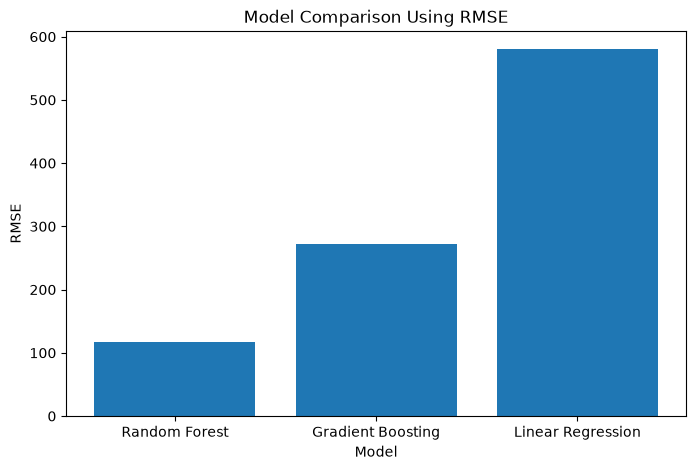

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.title("Model Comparison Using RMSE")
plt.ylabel("RMSE")
plt.xlabel("Model")

plt.show()